In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
from tqdm import tqdm
import gget
import scipy
import networkx as nx
from scipy.stats import zscore
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh

import anndata as an
import scanpy as sc
import scanpy.external as sce
import rapids_singlecell as rsc
import scvi

import cupy as cp
from cuml.manifold import TSNE
from cuml.decomposition import PCA
import cugraph
import cudf

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 345 ms, sys: 1.86 s, total: 2.2 s
Wall time: 7.96 s


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersio

In [3]:
sc.pp.filter_genes(adata, min_counts=1000)
adata

filtered out 12204 genes that are detected in less than 1000 counts


AnnData object with n_obs × n_vars = 15867 × 9208
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersion

In [4]:
adata.var.head()

,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_counts,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,feature_id
A1BG,False,False,False,10687,1.192232,0.784920,47.525287,24281.0,10.097491,10055.168169,False,0.761325,0.237293,-0.253306,0,False,ENSG00000121410
A4GALT,False,False,False,2460,0.157861,0.146574,87.921045,3215.0,8.075894,1683.183165,False,0.143174,0.080670,-0.068570,1,False,ENSG00000128274
AAAS,False,False,False,2348,0.129972,0.122192,88.470981,2647.0,7.881560,1373.636024,False,0.117840,-0.017842,-0.499156,0,False,ENSG00000094914
AACS,False,False,False,2428,0.139252,0.130372,88.078169,2836.0,7.950502,1470.167615,False,0.124899,0.024547,-0.391399,0,False,ENSG00000081760
AAGAB,False,False,False,4118,0.257979,0.229506,79.780026,5254.0,8.566935,2692.663068,False,0.224661,0.058847,-0.178342,0,False,ENSG00000103591


# Build Graphs

In [5]:
%%time
graphs = {}
data = {}
node_maps = {}  # maps: cluster_name → {int_id: gene_name}

for group_name, group in adata.obs.groupby('cluster_str'):
    print(f"Processing cluster: {group_name}")
    cell_idx = group.index
    gene_mask = ~adata.var['mt'] & ~adata.var['ribo'] & ~adata.var['hb']

    gdata = adata[cell_idx, gene_mask].copy().T  # genes x cells
    rsc.pp.pca(gdata)
    rsc.pp.neighbors(gdata, n_neighbors=1500)
    data[group_name] = gdata.copy()

    # Get sparse connectivities matrix
    conn = gdata.obsp['distances'].tocoo()
    rows = cp.asarray(conn.row)
    cols = cp.asarray(conn.col)
    vals = cp.asarray(conn.data)

    # Build GPU edge list
    edges = cudf.DataFrame({
        'src': rows,
        'dst': cols,
        'weight': vals
    })

    # Create the graph
    G = cugraph.Graph(directed=False)
    G.from_cudf_edgelist(edges, source='src', destination='dst', edge_attr='weight')

    # Store graph
    graphs[group_name] = G

    # Store mapping from integer node ID to gene name
    gene_names = gdata.obs_names.to_list()
    id_to_name = dict(enumerate(gene_names))
    node_maps[group_name] = id_to_name

print(f"\nConstructed graphs for {len(graphs)} clusters.")


<timed exec>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Processing cluster: C1
[2025-05-26 15:56:31.685] [CUML] [debug] n_neighbors=1500
[2025-05-26 15:56:31.685] [CUML] [debug] Calling knn graph run
[2025-05-26 15:56:31.685] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-26 15:56:32.188] [CUML] [debug] Done. Calling remove zeros
Processing cluster: C2
[2025-05-26 15:56:34.852] [CUML] [debug] n_neighbors=1500
[2025-05-26 15:56:34.852] [CUML] [debug] Calling knn graph run
[2025-05-26 15:56:34.852] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-26 15:56:35.348] [CUML] [debug] Done. Calling remove zeros
Processing cluster: C3
[2025-05-26 15:56:39.246] [CUML] [debug] n_neighbors=1500
[2025-05-26 15:56:39.247] [CUML] [debug] Calling knn graph run
[2025-05-26 15:56:39.247] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-26 15:56:39.738] [CUML] [debug] Done. Calling remove zeros
Processing cluster: C4
[2025-05-26 15:56:47.261] [CUML] [debug] n_neighbors=1500
[2025-05-26 15:56:47.261] [CUML] [debug] Calling knn gr

# Rank plots

<unknown>:12: SyntaxWarning: invalid escape sequence '\l'


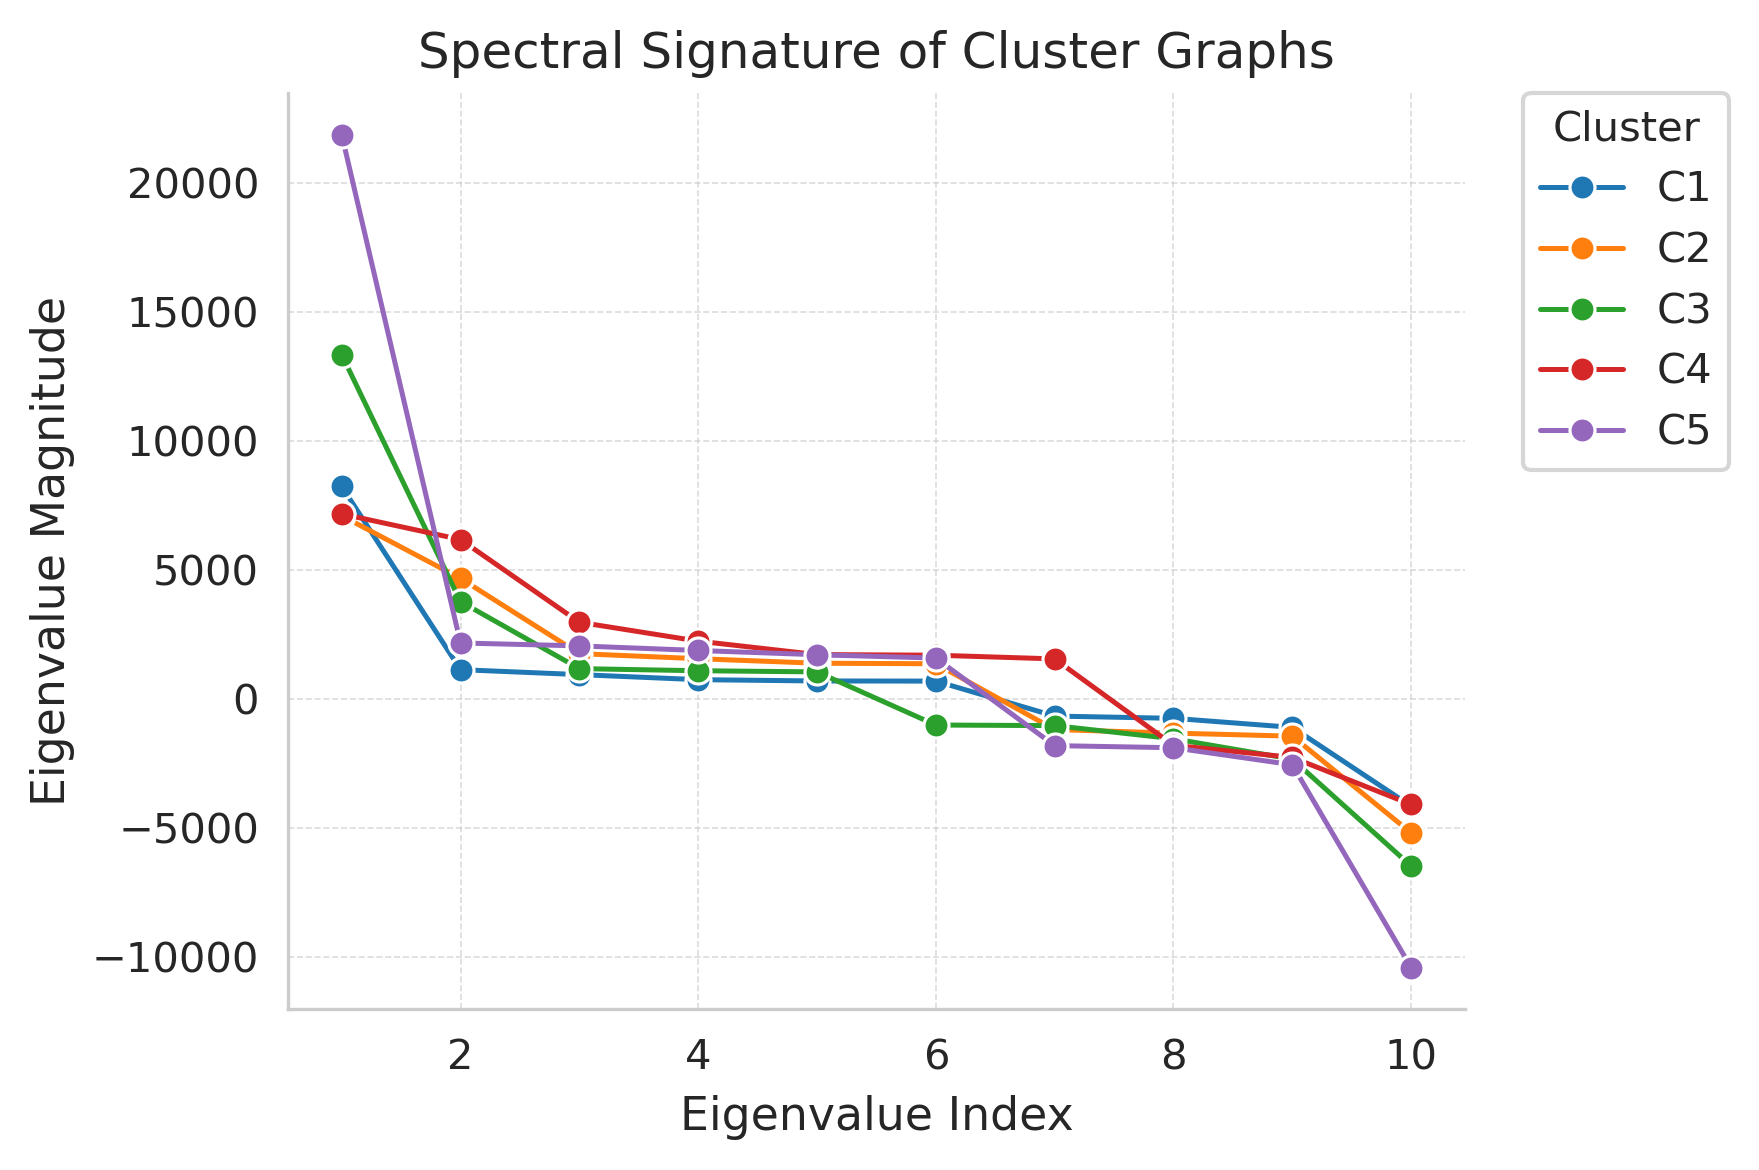

CPU times: user 6.26 s, sys: 816 ms, total: 7.08 s
Wall time: 6.83 s


In [6]:
%%time 
def top_k_spectrum(G, k=10):
    coo = G.view_edge_list().to_pandas()
    n = G.number_of_vertices()
    A = coo_matrix((coo['weight'], (coo['src'], coo['dst'])), shape=(n, n))
    eigvals = eigsh(A, k=k, return_eigenvectors=False)
    return np.sort(eigvals)[::-1]

spectra = {name: top_k_spectrum(G) for name, G in graphs.items()}

# Prepare dataframe
df = pd.DataFrame(spectra).T
df.columns = [f"$\lambda_{{{i+1}}}$" for i in range(df.shape[1])]
df['Cluster'] = df.index
df = df.melt(id_vars='Cluster', var_name='Eigenvalue Rank', value_name='Eigenvalue')
df['Rank'] = df['Eigenvalue Rank'].str.extract(r'\{(\d+)\}').astype(int)

# Plot
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 4
plt.rcParams['font.size'] = 10

sns.set_style("whitegrid")
sns.lineplot(
    data=df,
    x='Rank',
    y='Eigenvalue',
    hue='Cluster',
    marker='o',
    linewidth=1.2
)

plt.xlabel("Eigenvalue Index", fontsize=11)
plt.ylabel("Eigenvalue Magnitude", fontsize=11)
plt.title("Spectral Signature of Cluster Graphs", fontsize=12)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
sns.despine()
plt.show()

In [7]:
%%time
centralities = []

for name, G in graphs.items():
    print(f"Computing centralities for cluster: {name}")

    # Compute centralities
    pr = cugraph.pagerank(G)
    eig = cugraph.eigenvector_centrality(G)
    btw = cugraph.betweenness_centrality(G, normalized=True)

    # Convert to pandas
    pr_df = pr.to_pandas().rename(columns={'pagerank': 'PageRank'})
    eig_df = eig.to_pandas().rename(columns={'eigenvector_centrality': 'Eigenvector'})
    btw_df = btw.to_pandas().rename(columns={'betweenness_centrality': 'Betweenness'})

    # Merge on vertex ID
    df = pr_df.merge(eig_df, on='vertex').merge(btw_df, on='vertex')

    # Add cluster label and gene name
    df['Cluster'] = name
    df['Gene'] = df['vertex'].map(node_maps[name])

    centralities.append(df[['Cluster', 'Gene', 'PageRank', 'Eigenvector', 'Betweenness']])

# Combine all clusters
centrality_df = pd.concat(centralities, ignore_index=True)

centrality_df.head()


Computing centralities for cluster: C1
Computing centralities for cluster: C2
Computing centralities for cluster: C3
Computing centralities for cluster: C4
Computing centralities for cluster: C5
CPU times: user 3min 39s, sys: 1min 14s, total: 4min 53s
Wall time: 4min 55s


,Cluster,Gene,PageRank,Eigenvector,Betweenness
0,C1,MTERF1,0.000170,0.000048,0.001242
1,C1,LTO1,0.000163,0.000033,0.001111
2,C1,HPRT1,0.000162,0.000028,0.000906
3,C1,PI4K2A,0.000162,0.000027,0.000514
4,C1,ELMOD2,0.000159,0.000020,0.000569


In [8]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
centralities = []

for name, G in graphs.items():
    pr = cugraph.pagerank(G)
    df = pr.to_pandas()

    # Add cluster label
    df['Cluster'] = name

    # Use stored node map: int ID → gene name
    id_to_gene = node_maps[name]
    df['Gene'] = df['vertex'].map(id_to_gene)

    centralities.append(df[['Cluster', 'Gene', 'pagerank']])

# Combine and clean
centrality_df = pd.concat(centralities, ignore_index=True)
centrality_df = centrality_df.rename(columns={'pagerank': 'PageRank'})

# Rank genes by PageRank within each cluster
centrality_df['Rank'] = (
    centrality_df
    .groupby('Cluster')['PageRank']
    .rank(method='first', ascending=False)
    .astype(int)
)

centrality_df.head()

In [ ]:
# Select top N genes per cluster
top_n = 10
top_genes = (
    centrality_df[centrality_df['Rank'] <= top_n]
    .copy()
    .sort_values(['Cluster', 'Rank'])
)

# Set up subplots
clusters = top_genes['Cluster'].unique()
n_clusters = len(clusters)
n_cols = 3
n_rows = int(np.ceil(n_clusters / n_cols))

plt.figure(figsize=(4 * n_cols, 3 * n_rows))
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 9

for i, cluster in enumerate(clusters):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    data = top_genes[top_genes['Cluster'] == cluster]
    
    sns.barplot(
        data=data,
        x='Rank',
        y='Gene',
        ax=ax,
        order=data.sort_values('Rank')['Gene'],
        palette='Blues_d'
    )
    
    ax.invert_xaxis()  # Rank 1 on the left
    ax.set_title(f"Cluster {cluster}")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Gene")
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)

plt.tight_layout()
plt.suptitle("Top PageRank Genes per Cluster", y=1.02, fontsize=12)
plt.show()

In [ ]:


plt.figure(figsize=(7, 5))
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Subset to top N genes per cluster
top_n = 10
top_genes = (
    centrality_df[centrality_df['Rank'] <= top_n]
    .copy()
    .sort_values(['Cluster', 'Rank'])
)

# Plot
sns.swarmplot(
    data=top_genes,
    x="Rank",
    y="Gene",
    hue="Cluster",
    dodge=True,
    size=5,
    palette="deep"
)

plt.gca().invert_xaxis()  # Rank 1 on the left
plt.xlabel("Centrality Rank (Lower = More Central)")
plt.ylabel("Gene")
plt.title("Top 10 Central Genes per Cluster (PageRank Rank)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
sns.despine()

In [ ]:
centralities = []

for name, G in graphs.items():
    pr = cugraph.pagerank(G)
    df = pr.to_pandas()

    # Add cluster label
    df['Cluster'] = name

    # Map integer node IDs to gene names
    gene_names = adata.var_names[df['vertex'].values].to_numpy()
    df['Gene'] = gene_names

    centralities.append(df[['Cluster', 'Gene', 'pagerank']])

# Format centralities into a tidy DataFrame
df = pd.DataFrame([
    {"Cluster": cluster, "PageRank": val}
    for cluster, values in centralities.items()
    for val in values
])

# Plot: violin + box overlay
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 4
plt.rcParams['font.size'] = 10

sns.set_style("whitegrid")
sns.violinplot(
    data=df,
    x="Cluster",
    y="PageRank",
    inner=None,
    color=".8",
    linewidth=0.5
)
sns.boxplot(
    data=df,
    x="Cluster",
    y="PageRank",
    whis=1.5,
    width=0.3,
    showcaps=False,
    boxprops={'facecolor':'white', 'edgecolor':'black'},
    medianprops={'color':'black'},
    whiskerprops={'color':'black'},
    showfliers=False,
)

plt.yscale('log')  # PageRank is usually power-law distributed
plt.xlabel("Cluster", fontsize=11)
plt.ylabel("PageRank Centrality (log scale)", fontsize=11)
plt.title("Distribution of PageRank Centrality per Cluster", fontsize=12)
plt.tight_layout()
sns.despine()
plt.show()

In [ ]:
break

In [ ]:
%%time
cluster_corrs = {}
layer = 'log_norm'

clusters = adata.obs['cluster_str'].unique()
print(f"Computing GPU-accelerated gene-gene correlations for {len(clusters)} clusters...\n")

for cluster in clusters:
    print(f"> Processing cluster: {cluster}")

    idx = adata.obs['cluster_str'] == cluster
    X = adata[idx].layers[layer]

    # Ensure sparse CSR
    if not sparse.issparse(X):
        X = sparse.csr_matrix(X)

    # Convert to dense and push to GPU
    X_gpu = cp.array(X.toarray())  # shape: cells x genes

    # Center and scale (mean=0, std=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_gpu)

    # Compute correlation: (X.T @ X) / (n - 1)
    n = X_scaled.shape[0]
    corr_gpu = (X_scaled.T @ X_scaled) / (n - 1)

    # Clip to [-1, 1] for numeric stability
    corr_gpu = cp.clip(corr_gpu, -1.0, 1.0)

    # Convert back to CPU pandas DataFrame
    corr_df = pd.DataFrame(cp.asnumpy(corr_gpu), index=adata.var_names, columns=adata.var_names)
    cluster_corrs[cluster] = corr_df

    print(f"  Done. Matrix shape: {corr_df.shape}\n")
    break

print("All clusters processed.")

In [ ]:
# %%time

# # Use the log-normalized layer
# layer = 'log_norm'  # or use .X if already log-normalized

# # Store results in a dictionary
# cluster_corrs = {}

# for cluster in adata.obs['cluster_str'].unique():
#     # Subset the data
#     idx = adata.obs['cluster_str'] == cluster
#     X = adata[idx].layers[layer]

#     # Convert to dense if needed
#     if not isinstance(X, np.ndarray):
#         X = X.toarray()
    
#     # Compute correlation matrix
#     df = pd.DataFrame(X, columns=adata.var_names)
#     corr_matrix = df.corr(method='pearson')  # or use 'spearman'

#     cluster_corrs[cluster] = corr_matrix
#     break
